## Setting up environment for Colab

In [1]:
from google.colab import drive

drive.mount("/content/drive")


Mounted at /content/drive


In [2]:
import sys
from google.colab import userdata

config_path = userdata.get('CONFIG_PATH')

sys.path.append(config_path)

from config import BASE_PATH, DATA_PATH, SRC_PATH, SAVED_CHECKPOINTS_PATH

## Week 4 Session 4: Generalization + Robustness

---

### Learning Objectives

- **Demonstration**:  
  - Identify **potential bias dimensions** in misinformation detection.
  - Analyze model performance across these dimensions, e.g.:
    - **Source/Publisher bias**
    - **Linguistic complexity** (e.g., simplified articles, non-native speakers)
    - **Industry/Sector bias**
  - Implement **fairness metrics** for classification tasks:
    - Demographic Parity
    - Equalized Odds
    - Calibration
  - Visualize **bias and fairness trade-offs** (e.g., Pareto frontiers, delta plots).
  - Demonstrate simple **post-hoc bias mitigation** approaches.
  - Continue applying **post-hoc bias mitigation** techniques.
  - Practice balancing **performance vs. bias mitigation**.


## Libraries & Setup

In this session, we will use:

- **Pandas**, **NumPy** for data handling
- **Scikit-learn** for metrics, splitting, and pipeline utilities
- **XGBoost** for training our classifier
- **Fairlearn** for fairness metrics and bias mitigation
- **Matplotlib** or **Seaborn** for visualizing fairness-accuracy trade-offs

In [3]:
!pip install xgboost fairlearn numpy pandas scikit-learn xgboost nltk seaborn matplotlib textstat shap nlpaug

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.6/251.6 kB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.1/177.1 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.5/410.5 kB 19.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 23.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 51.1 MB/s eta 0:00:00
  Attempting uninstall: scipy
    Found existing installation: scipy 1.16.3
    Uninstalling scipy-1.16.3:
      Successfully uninstalled scipy-1.16.3


In [4]:
!pip install {SRC_PATH}

Processing ./drive/MyDrive/MASAID/AI_Project_Course/Misinformation/repo/src
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for misinformation_detection: filename=misinformation_detection-1.0.0-py3-none-any.whl size=20155 sha256=f567638b904d6cfcea693bc91198ddeb0e4dab5119b5f0cda653fda461a4fd4e
  Stored in directory: /tmp/pip-ephem-wheel-cache-t5vixo9s/wheels/46/67/19/6967c24d7ffe355b16d9bd45b2a6576a3fa548c7b58c981aee
Successfully built misinformation_detection


## Loading XGBoost Baseline

In [5]:
from misinformation_detection.data import prepare_text_structured_features_full
from pathlib import Path

X_train_combined, X_test_combined, X_structured_train_full, X_structured_test_full, y_train, y_test, vectorizer = prepare_text_structured_features_full(
    DATA_PATH / Path("processed/fnn_lemmatized.csv")
)

Model loaded from /content/drive/MyDrive/MASAID/AI_Project_Course/Misinformation/repo/data/saved_checkpoints/xgboost_model.joblib
Accuracy: 0.8233, Precision: 0.7641, Recall: 0.3385, F1-score: 0.4692


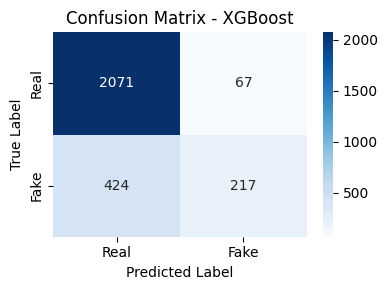

(0.8233177401943145,
 0.7640845070422535,
 0.33853354134165364,
 0.46918918918918917)

In [6]:

from misinformation_detection.models import XGBoostModel

# Convert labels to numeric: real=0, fake=1
y_train_encoded = y_train.map({"real": 0, "fake": 1})
y_test_encoded = y_test.map({"real": 0, "fake": 1})

# 1. Initialize and train
xgb_clf = XGBoostModel(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    use_label_encoder=False,
    eval_metric="logloss",
    random_state=42
)

xgb_clf.load_model(SAVED_CHECKPOINTS_PATH / Path("xgboost_model.joblib"))

xgb_clf.evaluate(X_test_combined, y_test_encoded)

**Note:** The low recall for `fake` shows imbalance — a good starting point for the **fairness & bias** module:
- Next, analyze if performance differs by `source`, `publisher group`, or `reading ease`!
- Then, apply fairness metrics and mitigation (e.g., re-weighting or post-processing).

## Analyze Where the Model Fails

Now let’s identify **which examples the XGBoost model predicts incorrectly** and explore patterns in these failures — for example by looking at the associated news source or topic.

In [7]:
import pandas as pd

# === Make predictions ===
y_test_preds = xgb_clf.predict(X_test_combined)

# Always reset index to align properly
X_structured_test_full = X_structured_test_full.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

X_structured_test_full["true_label"] = y_test
X_structured_test_full["predicted_label"] = pd.Series(y_test_preds).map({0: "real", 1: "fake"})

print(X_structured_test_full[["id", "title", "true_label", "predicted_label"]].head())

                 id                                              title  \
0  gossipcop-928730  Taylor Swift goes back to country roots with n...   
1  gossipcop-876401  Taylor Swift’s ‘Look What You Made Me Do’ Vide...   
2  gossipcop-871753  Miley pens sweet message to Liam Hemsworth and...   
3  gossipcop-890574  Watch Kim Kardashian Devour Pizza & Ice Cream ...   
4  gossipcop-871119  TLC cut ties with Derick Dillard, Jill Duggar’...   

  true_label predicted_label  
0       real            real  
1       real            real  
2       real            real  
3       real            real  
4       real            real  


## Analyzing & Visualizing Prediction Accuracy by News Source

In this analysis, we will:

1. **Mark correct predictions** by comparing true vs. predicted labels.  
2. **Aggregate counts** of correct and incorrect predictions for each news source.  
3. **Compute totals and percentages** of correct/incorrect predictions per source.  
4. **Visualize** the breakdown using a side-by-side bar chart for quick comparison.

This combined table and plot help you spot which sources your model handles well and where it tends to fail, guiding targeted improvements.  

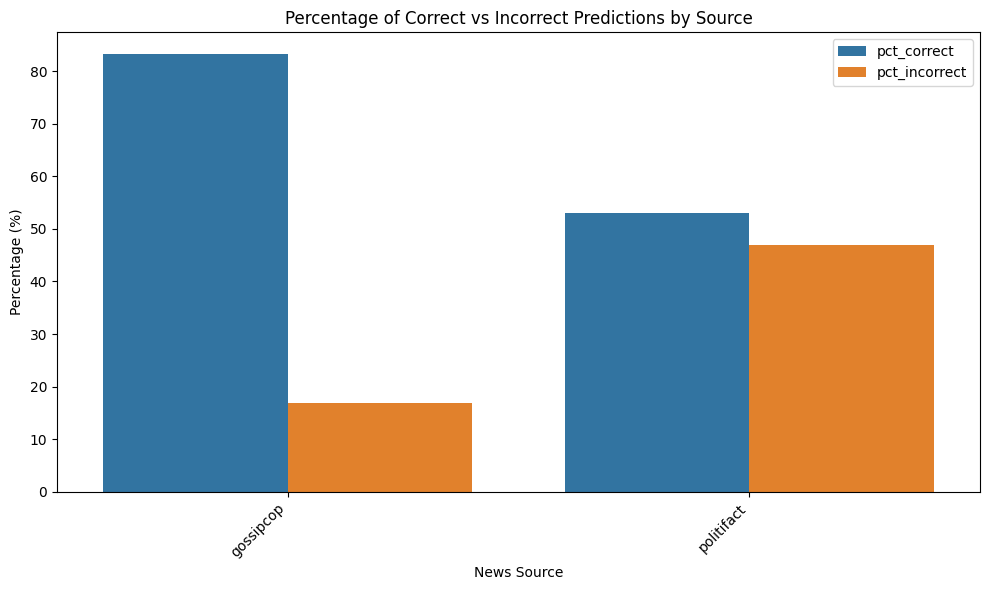

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Mark correct predictions
X_structured_test_full["is_correct"] = (
    X_structured_test_full["true_label"] == X_structured_test_full["predicted_label"]
)

# Count correct and incorrect per source
counts = (
    X_structured_test_full
    .groupby(["dataset_source", "is_correct"])
    .size()
    .unstack(fill_value=0)
)

# Calculate totals and percentages
counts["total"] = counts.sum(axis=1)
counts["pct_correct"] = counts[True] / counts["total"] * 100
counts["pct_incorrect"] = counts[False] / counts["total"] * 100

# Reset index for plotting
plot_df = counts.reset_index()

# Plot percent correct and incorrect side by side
plt.figure(figsize=(10, 6))
sns.barplot(
    data=plot_df.melt(
        id_vars="dataset_source",
        value_vars=["pct_correct", "pct_incorrect"],
        var_name="Outcome",
        value_name="Percentage"
    ),
    x="dataset_source",
    y="Percentage",
    hue="Outcome"
)
plt.xticks(rotation=45, ha="right")
plt.title("Percentage of Correct vs Incorrect Predictions by Source")
plt.ylabel("Percentage (%)")
plt.xlabel("News Source")
plt.legend(title="")
plt.tight_layout()
plt.show()

## Website-Level Accuracy by Sample Count

In this analysis, we:

1. **Select the top 10 domains** for each source (`gossipcop` and `politifact`) based on the number of test samples.  
2. **Compute accuracy** for each of these domains.  
3. **Visualize** with side-by-side bar charts showing accuracy (%) for the top domains by sample count.

This helps you understand performance not just on the most accurate sites, but on the ones where you have the most data—ensuring your insights are statistically meaningful.  

/tmp/ipython-input-4283658991.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipython-input-4283658991.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


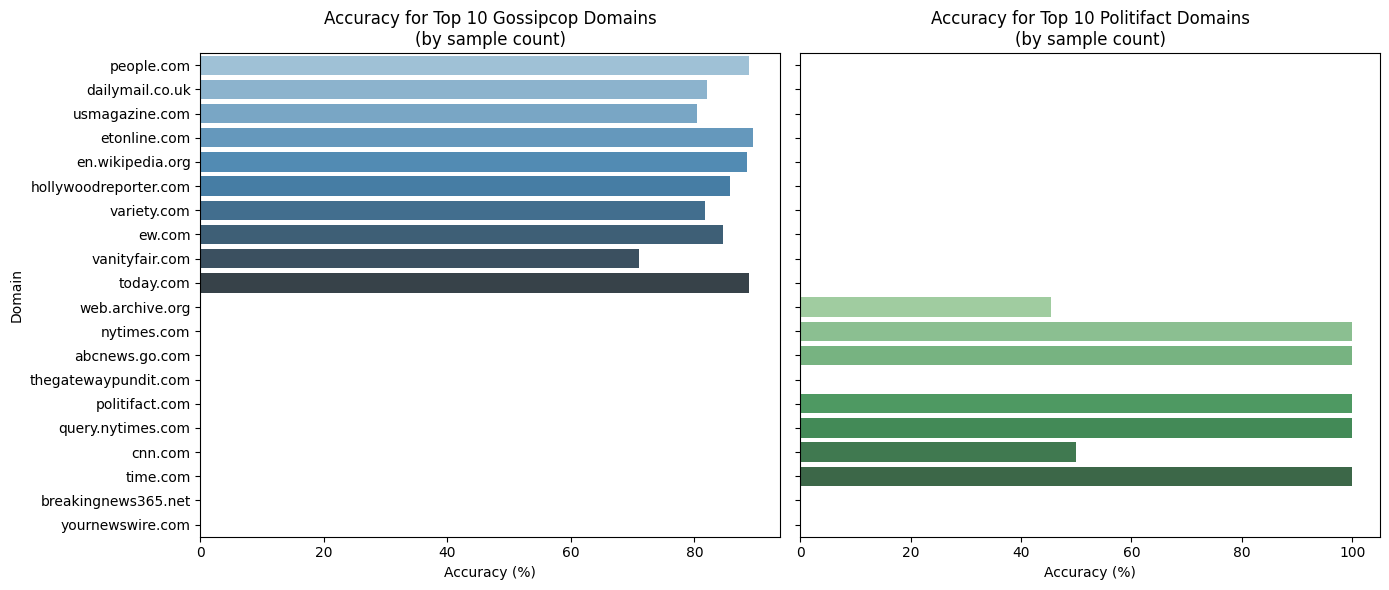

In [9]:

import matplotlib.pyplot as plt
import seaborn as sns

# Ensure correctness column exists
if "is_correct" not in X_structured_test_full:
    X_structured_test_full["is_correct"] = (
        X_structured_test_full["true_label"] == X_structured_test_full["predicted_label"]
    )

def plot_top_by_count(df, source_name, ax, palette):
    # Filter by source and compute domain counts
    subset = df[df["dataset_source"] == source_name]
    domain_counts = subset["source_domain"].value_counts().head(10)
    top_domains = domain_counts.index.tolist()

    # Compute accuracy for these domains
    acc = (
        subset[subset["source_domain"].isin(top_domains)]
        .groupby("source_domain")["is_correct"]
        .mean()
        .reindex(top_domains)  # preserve order by sample count
        * 100
    ).reset_index().rename(columns={"is_correct": "accuracy_pct"})

    # Plot
    sns.barplot(
        data=acc,
        x="accuracy_pct",
        y="source_domain",
        ax=ax,
        palette=palette
    )
    ax.set_title(f"Accuracy for Top 10 {source_name.title()} Domains\n(by sample count)")
    ax.set_xlabel("Accuracy (%)")
    ax.set_ylabel("Domain")

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

plot_top_by_count(X_structured_test_full, "gossipcop", axes[0], "Blues_d")
plot_top_by_count(X_structured_test_full, "politifact", axes[1], "Greens_d")

plt.tight_layout()
plt.show()

## Fairness & Bias: XGBoost Misinformation Model

**Objective:**  
Check if your XGBoost model shows biased performance across sensitive or meaningful groups.

### 1) Identify possible bias dimensions:
- **Source/Publisher** — e.g., mainstream vs. niche domains.
- **Reading Complexity** — e.g., `flesch_reading_ease`

### 2) Compute performance by group:
- Add predictions to your `X_structured_test_full` DataFrame.
- Calculate group-wise **accuracy**, **precision**, **recall**, **F1**.
- Use `groupby()` for dimensions like `source_domain_grouped` or quantiles of reading ease.

### 3) Visualize:
- Use bar plots for group performance.
- Optional: Make **Pareto or delta-metric plots** to show trade-offs.

### 4) Interpret:
- Are some groups consistently misclassified more?
- Is there a pattern that could lead to reputational or regulatory risks?

**Next step:** Apply a mitigation if needed:
- Re-weighting, re-sampling, or simple post-processing.

Let’s start with group-level metrics first!

  source_domain_grouped  flesch_bin  y_true  y_pred
0                 Other  Medium-Low       0       0
1                 Other  Medium-Low       0       0
2                 Other        High       0       0
3                 Other         Low       0       0
4                 Other        High       0       0

=== Group Metrics: source_domain_grouped ===
    source_domain_grouped  count  accuracy  precision    recall        f1
9           inquisitr.com     25  0.960000   1.000000  0.947368  0.972973
12            thewrap.com     31  0.935484   0.000000  0.000000  0.000000
1           billboard.com     32  0.906250   0.000000  0.000000  0.000000
5            etonline.com    104  0.894231   0.500000  0.363636  0.421053
13              today.com     36  0.888889   0.000000  0.000000  0.000000
10             people.com    269  0.888476   0.400000  0.068966  0.117647
4        en.wikipedia.org     96  0.885417   0.000000  0.000000  0.000000
8   hollywoodreporter.com     49  0.857143   0.000

/tmp/ipython-input-3527970618.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for group_name, group_df in df.groupby(group_col):


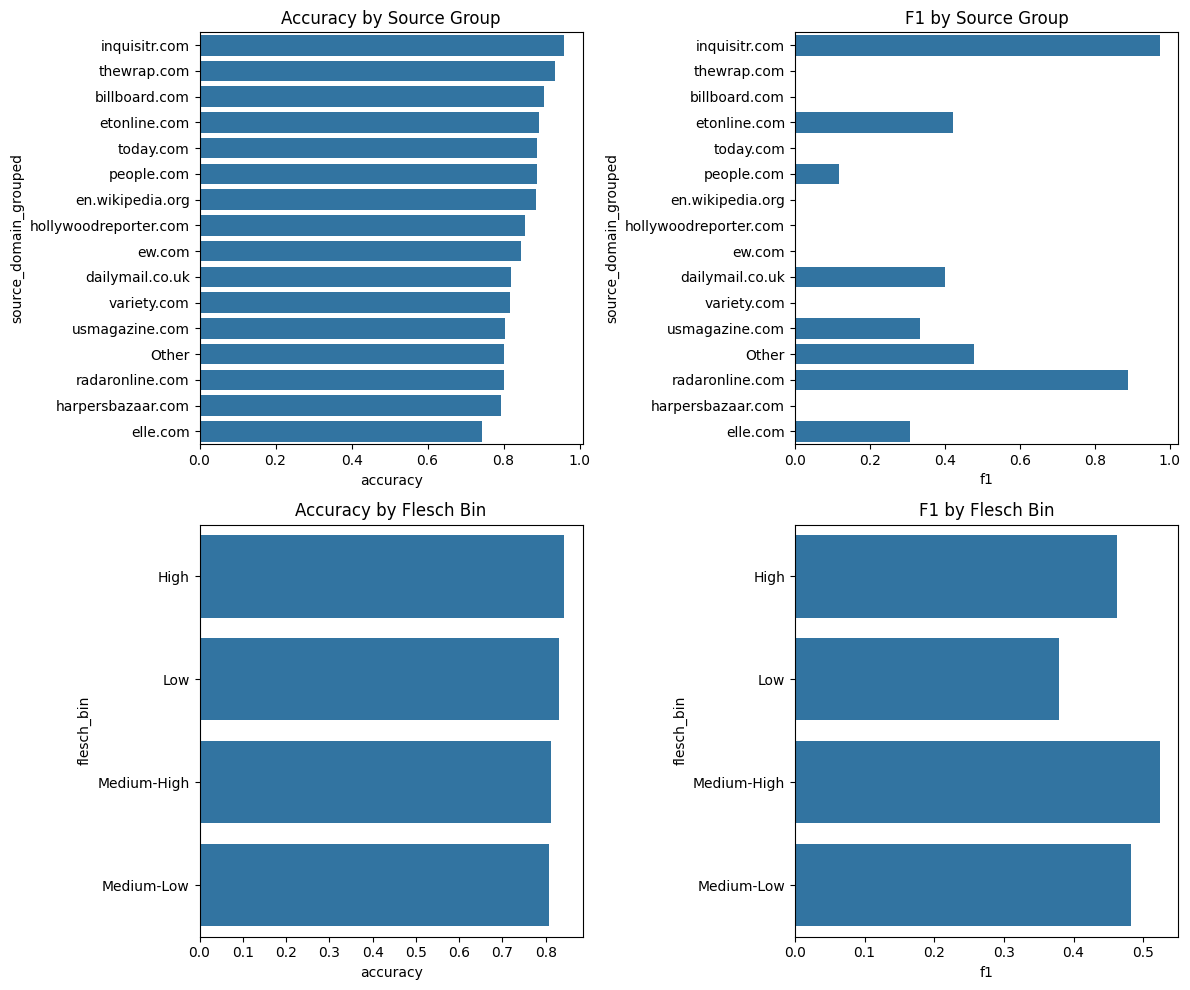

In [10]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt

# === 1) Attach true & predicted labels to test DataFrame ===
X_structured_test_full = X_structured_test_full.copy()
X_structured_test_full["y_true"] = y_test_encoded.values
xgb_preds = xgb_clf.predict(X_test_combined)
X_structured_test_full["y_pred"] = xgb_preds

# === 2) Bin Flesch Reading Ease ===
# Lower score = more complex, higher = easier to read
X_structured_test_full["flesch_bin"] = pd.qcut(
    X_structured_test_full["flesch_reading_ease"],
    q=4,
    labels=["Low", "Medium-Low", "Medium-High", "High"]
)

print(X_structured_test_full[[ "source_domain_grouped", "flesch_bin", "y_true", "y_pred"]].head())

# === 3) Function to compute group metrics ===
def compute_group_metrics(df, group_col):
    group_metrics = []
    for group_name, group_df in df.groupby(group_col):
        y_true_group = group_df["y_true"]
        y_pred_group = group_df["y_pred"]
        acc = accuracy_score(y_true_group, y_pred_group)
        precision = precision_score(y_true_group, y_pred_group, zero_division=0)
        recall = recall_score(y_true_group, y_pred_group, zero_division=0)
        f1 = f1_score(y_true_group, y_pred_group, zero_division=0)
        group_metrics.append({
            group_col: group_name,
            "count": len(group_df),
            "accuracy": acc,
            "precision": precision,
            "recall": recall,
            "f1": f1
        })
    return pd.DataFrame(group_metrics).sort_values("accuracy", ascending=False)

# === 4) Compute & show for source_domain_grouped ===
print("\n=== Group Metrics: source_domain_grouped ===")
source_metrics = compute_group_metrics(X_structured_test_full, "source_domain_grouped")
print(source_metrics)

# === 5) Compute & show for flesch_bin ===
print("\n=== Group Metrics: flesch_reading_ease bins ===")
flesch_metrics = compute_group_metrics(X_structured_test_full, "flesch_bin")
print(flesch_metrics)

# === 6) Plot ===
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

sns.barplot(data=source_metrics, x="accuracy", y="source_domain_grouped", ax=axes[0][0]).set(title="Accuracy by Source Group")
sns.barplot(data=source_metrics, x="f1", y="source_domain_grouped", ax=axes[0][1]).set(title="F1 by Source Group")

sns.barplot(data=flesch_metrics, x="accuracy", y="flesch_bin", ax=axes[1][0]).set(title="Accuracy by Flesch Bin")
sns.barplot(data=flesch_metrics, x="f1", y="flesch_bin", ax=axes[1][1]).set(title="F1 by Flesch Bin")

plt.tight_layout()
plt.show()

## Fairness & Bias Review — XGBoost Misinformation Classifier

**Key findings from group analysis:**

1. **Source Group Performance**
    - The model shows clear variation in accuracy and F1 across different source domains.
    - Some sources like `radaronline.com` and `en.wikipedia.org` have strong performance (high accuracy and F1).
    - Others, like `billboard.com` and `dailymail.co.uk`, have noticeably lower metrics, especially F1 — indicating poor true positive predictions for these groups.
    - This suggests potential **source/publisher bias**, which could harm credibility if certain outlets are consistently misclassified.

2. **Reading Complexity (Flesch Reading Ease)**
    - Performance is relatively stable across `High`, `Medium-High`, `Medium-Low`, and `Low` bins.
    - This indicates the model handles different text complexities fairly consistently.
    - No major fairness concern detected here — but it’s good practice to monitor this over time.

**Overall takeaway:**
- The main bias risk lies in **source/publisher disparities**, where some domains have lower F1.
- Next, we should investigate the root cause — e.g., small sample size, domain-specific language, or structural features.
- If needed, we can apply simple bias mitigation: **group re-weighting**, **re-sampling**, or **threshold adjustment** for under-served groups.

**Action items:**
- Inspect group sizes and confusion matrices for weak groups.
- Try a bias mitigation approach and measure fairness trade-offs against overall performance.

## Fairness Mitigation: Group Re-weighting for XGBoost

We apply a simple bias mitigation by **re-weighting** samples based on their `source_domain_grouped` frequency:

- **Add Group Info:** Include each sample’s group label.
- **Compute Frequencies:** Check how often each group appears in the training data.
- **Inverse Frequency:** Assign higher weights to underrepresented groups.
- **Train with Weights:** Use `sample_weight` in XGBoost to balance the impact.
- **Re-Evaluate:** Compare the updated classification metrics to see if group disparities have improved.

This approach helps ensure that all groups are treated more equitably during training.

In [11]:
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier

# === 1) Add source group to training data for re-weighting ===
X_train_combined["source_domain_grouped"] = X_structured_train_full["source_domain_grouped"]

# === 2) Compute group frequencies ===
group_freq = X_train_combined["source_domain_grouped"].value_counts(normalize=True).to_dict()

# === 3) Compute inverse frequency weights ===
X_train_combined["group_weight"] = X_train_combined["source_domain_grouped"].map(lambda g: 1 / group_freq[g])

# === 4) Prepare final data ===
sample_weights = X_train_combined["group_weight"].values
X_train_final = X_train_combined.drop(columns=["source_domain_grouped", "group_weight"])

# === 5) Re-train XGBoost with sample weights ===
xgb_clf_reweighted = XGBClassifier(
    use_label_encoder=False,
    eval_metric="logloss",
    random_state=42
)
xgb_clf_reweighted.fit(X_train_final, y_train_encoded, sample_weight=sample_weights)

# === 6) Evaluate ===
xgb_preds_reweighted = xgb_clf_reweighted.predict(X_test_combined)

from sklearn.metrics import classification_report
print(classification_report(y_test_encoded, xgb_preds_reweighted))

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [19:19:12] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


              precision    recall  f1-score   support

           0       0.84      0.94      0.88      2138
           1       0.65      0.39      0.48       641

    accuracy                           0.81      2779
   macro avg       0.74      0.66      0.68      2779
weighted avg       0.79      0.81      0.79      2779




=== Group Metrics: source_domain_grouped (Re-weighted) ===
    source_domain_grouped  count  accuracy  precision    recall        f1
12            thewrap.com     31  0.935484   0.000000  0.000000  0.000000
9           inquisitr.com     25  0.920000   1.000000  0.894737  0.944444
1           billboard.com     32  0.906250   0.000000  0.000000  0.000000
5            etonline.com    104  0.903846   0.571429  0.363636  0.444444
11        radaronline.com     30  0.900000   0.896552  1.000000  0.945455
4        en.wikipedia.org     96  0.895833   0.000000  0.000000  0.000000
8   hollywoodreporter.com     49  0.877551   0.500000  0.166667  0.250000
10             people.com    269  0.877323   0.375000  0.206897  0.266667
6                  ew.com     39  0.871795   0.600000  0.500000  0.545455
13              today.com     36  0.861111   0.000000  0.000000  0.000000
15            variety.com     49  0.857143   1.000000  0.222222  0.363636
14         usmagazine.com    123  0.804878   0.57142

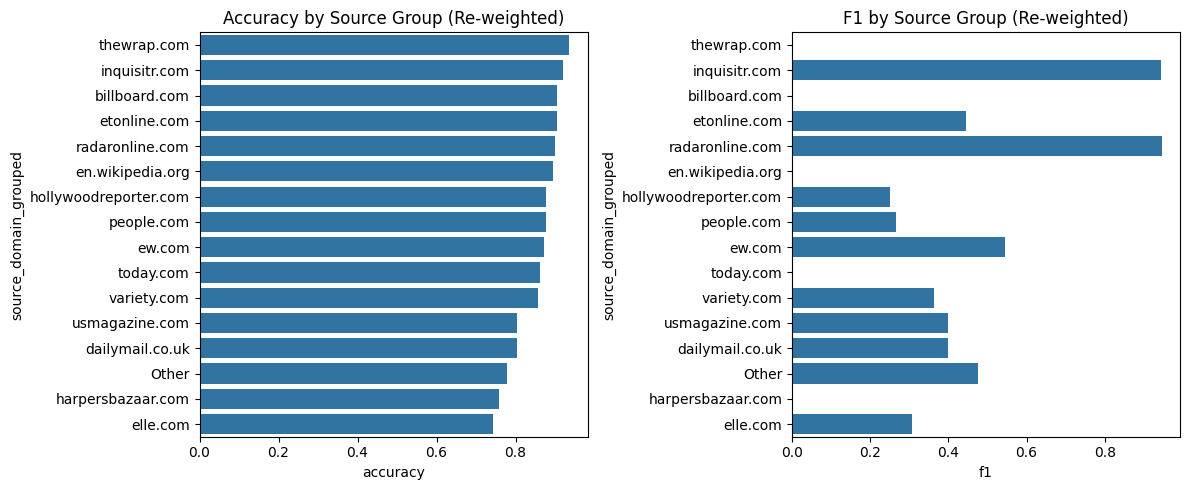

In [12]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt

# === 1) Attach new predictions ===
X_structured_test_full_rew = X_structured_test_full.copy()
X_structured_test_full_rew["y_true"] = y_test_encoded.values
X_structured_test_full_rew["y_pred"] = xgb_preds_reweighted  # from your re-weighted model

# === 2) Compute group metrics ===
def compute_group_metrics(df, group_col):
    group_metrics = []
    for group_name, group_df in df.groupby(group_col):
        y_true_group = group_df["y_true"]
        y_pred_group = group_df["y_pred"]
        acc = accuracy_score(y_true_group, y_pred_group)
        precision = precision_score(y_true_group, y_pred_group, zero_division=0)
        recall = recall_score(y_true_group, y_pred_group, zero_division=0)
        f1 = f1_score(y_true_group, y_pred_group, zero_division=0)
        group_metrics.append({
            group_col: group_name,
            "count": len(group_df),
            "accuracy": acc,
            "precision": precision,
            "recall": recall,
            "f1": f1
        })
    return pd.DataFrame(group_metrics).sort_values("accuracy", ascending=False)

# === 3) Source group ===
print("\n=== Group Metrics: source_domain_grouped (Re-weighted) ===")
source_metrics_rew = compute_group_metrics(X_structured_test_full_rew, "source_domain_grouped")
print(source_metrics_rew)

# === 4) Plot ===
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.barplot(data=source_metrics_rew, x="accuracy", y="source_domain_grouped", ax=axes[0]).set(title="Accuracy by Source Group (Re-weighted)")
sns.barplot(data=source_metrics_rew, x="f1", y="source_domain_grouped", ax=axes[1]).set(title="F1 by Source Group (Re-weighted)")

plt.tight_layout()
plt.show()

## External Test on “Bloomberg+GPT-4o” Dataset

In this section, we’ll evaluate our existing misinformation detector on a brand-new dataset created by taking real Bloomberg news articles and editing them with the GPT-4o model.

---

### 1. What Is This Dataset?  
- **Source:** Original Bloomberg news (real).  
- **Modification:** GPT-4o has rephrased or altered each story to simulate a “fake” counterpart.  
- **Purpose:** Gauge how well our model handles AI-generated perturbations of real content.

---

### 2. Preparation Steps  
1. **Load the CSV** (columns: `real_news`, `fake_news`).  
2. **Melt to long format** → two columns:  
   - `article_cleaned` (apply your standard cleaning pipeline)  
   - `label` (“real” vs. “fake”)  
3. **Extract Structured Features** exactly as in training:  
   - Word & sentence counts, avg. word length, lexical richness  
   - POS-ratios, punctuation/exclamation counts, stopword ratio  
   - Readability (Flesch), clickbait flag  
4. **TF-IDF Transform** using your fitted vectorizer.  
5. **Combine** TF-IDF and structured features into one DataFrame.

---

### 3. Prediction & Evaluation  
- **Load** your trained model (XGBoost / ensemble).  
- **Predict** on the combined test features.  
- **Compute** accuracy, precision, recall, F1-score.  
- **Plot** a confusion matrix for quick visual insight.

---

**Goal:** See whether AI-edited versions of real news “fool” your detector and identify any feature gaps you need to address.  

In [13]:
import pandas as pd

# Load external Bloomberg+GPT-4o test CSV (raw articles)
ext_df = pd.read_csv(DATA_PATH / Path("raw/bloomberg_fake_news_dataset.csv"))

# Melt into long format keeping only the raw article text
ext_long = (
    ext_df
    .rename(columns={"real_news": "real", "fake_news": "fake"})
    .melt(value_vars=["real", "fake"],
          var_name="label",
          value_name="article")
)

print(f"Loaded external test set with {len(ext_long)} examples")
ext_long.head()
y_ext_true = ext_long["label"]

Loaded external test set with 200 examples


## Preparing New Dataset for Evaluation

In this step, we start preparing the new external test dataset for model evaluation.  
We:

- Define a text cleaning function to normalize the raw article text.  
- Remove URLs, HTML tags, non-ASCII/control characters, and extra whitespace.  
- Apply the cleaning function to each article in the external dataset.  
- Preview some samples to confirm that the cleaning worked as expected.

This ensures that the text is in the same format as the training data for consistent feature extraction.

In [14]:
import re

# Define text cleaning function
def clean_text(text):
    text = str(text).lower().strip()
    text = re.sub(r"http\S+|www\S+", "", text)              # Remove URLs
    text = re.sub(r"<[^>]+>", "", text)                     # Remove HTML tags
    text = re.sub(r"[^\x20-\x7E]", " ", text)               # Remove non-ASCII/control characters
    text = re.sub(r"\s+", " ", text)                        # Normalize whitespace
    return text

# Clean the external test articles
ext_long["article_cleaned"] = ext_long["article"].apply(clean_text)

# Preview before/after on random samples
ext_long[["article", "article_cleaned"]].sample(5)

,article,article_cleaned
113,New York Times Co. (NYT) experienced its large...,new york times co. (nyt) experienced its large...
13,New York Times Climbs After Mexican Billionair...,new york times climbs after mexican billionair...
145,Euro-area government leaders will meet Oct. 19...,euro-area government leaders will meet oct. 19...
85,Vietnam Jan-July Balance of Payments Surplus E...,vietnam jan-july balance of payments surplus e...
159,U.S. 30-year bonds experienced a significant d...,u.s. 30-year bonds experienced a significant d...


## Repeat Preprocessing for External Dataset

Here, we repeat the same lemmatization step we used for the main training dataset to ensure consistency.

- Download necessary NLTK resources (`punkt` tokenizer and `wordnet` lemmatizer).
- Define a simple lemmatization function that tokenizes each article and lemmatizes each word.
- Apply this function to the cleaned text in the external dataset.
- Preview the cleaned vs. lemmatized text to confirm that the pipeline matches the main dataset.

This guarantees that the model sees text processed the same way during training and testing.

In [15]:
import nltk
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

# Download required NLTK data
nltk.download("punkt")
nltk.download("wordnet")
nltk.download('punkt_tab')

lemmatizer = WordNetLemmatizer()

def lemmatize_text(text):
    tokens = word_tokenize(text)
    return " ".join(lemmatizer.lemmatize(token) for token in tokens)

# Drop the original article column
ext_long = ext_long.drop(columns=["article"])

# Apply to the cleaned external articles
ext_long["article_lemmatized"] = ext_long["article_cleaned"].apply(lemmatize_text)

# Quick preview
ext_long[["article_cleaned", "article_lemmatized"]].head()

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


,article_cleaned,article_lemmatized
0,"ivory coast keeps cocoa export tax below 22%, ...","ivory coast keep cocoa export tax below 22 % ,..."
1,usda boxed beef cutout closing prices for octo...,usda boxed beef cutout closing price for octob...
2,u.s. september small business jobs summary b y...,u.s. september small business job summary b y ...
3,greece s gsee says won t meet for talks with t...,greece s gsee say won t meet for talk with tro...
4,clean-tech companies should get 10-year tax br...,clean-tech company should get 10-year tax brea...


## Creating Basic Linguistic Features for External Dataset

Next, we generate the same core text-based features for the external dataset that we used in our training data:

- **Word Count:** Total number of tokens in each article.
- **Sentence Count:** Number of sentences detected.
- **Average Word Length:** Mean length of words in each article.
- **Lexical Richness:** Ratio of unique words to total words.

These features capture basic linguistic patterns and help the model generalize better when predicting on new data.

In [16]:
import nltk
from nltk.tokenize import word_tokenize, sent_tokenize
import numpy as np

# Define helper functions
def word_count(text):
    tokens = word_tokenize(text)
    return len(tokens)

def sentence_count(text):
    sentences = sent_tokenize(text)
    return len(sentences)

def avg_word_length(text):
    tokens = word_tokenize(text)
    if len(tokens) == 0:
        return 0
    return np.mean([len(w) for w in tokens])

def lexical_richness(text):
    tokens = word_tokenize(text)
    if len(tokens) == 0:
        return 0
    unique_tokens = set(tokens)
    return len(unique_tokens) / len(tokens)

# Apply to the cleaned article text of your new dataset
ext_long["word_count"] = ext_long["article_cleaned"].apply(word_count)
ext_long["sentence_count"] = ext_long["article_cleaned"].apply(sentence_count)
ext_long["avg_word_length"] = ext_long["article_cleaned"].apply(avg_word_length)
ext_long["lexical_richness"] = ext_long["article_cleaned"].apply(lexical_richness)

# Preview
ext_long[[
    "article_cleaned",
    "word_count",
    "sentence_count",
    "avg_word_length",
    "lexical_richness"
]].head(3)

,article_cleaned,word_count,sentence_count,avg_word_length,lexical_richness
0,"ivory coast keeps cocoa export tax below 22%, ...",489,16,4.496933,0.525562
1,usda boxed beef cutout closing prices for octo...,1860,22,4.087634,0.394624
2,u.s. september small business jobs summary b y...,71,2,4.563380,0.732394


## Add Advanced Features for External Dataset

- POS tag ratios, punctuation/exclamation counts, stopword ratio, readability score, and clickbait flag.
- Same functions as training.
- Keeps everything aligned.

In [17]:
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from textstat import flesch_reading_ease
import pandas as pd

# Download necessary NLTK resources
nltk.download('punkt')
nltk.download('averaged_perceptron_tagger')
nltk.download('stopwords')
nltk.download('averaged_perceptron_tagger_eng')


stop_words = set(stopwords.words('english'))

# --- POS Tag Ratios ---
def pos_ratios(text):
    tokens = word_tokenize(text)
    if len(tokens) == 0:
        return pd.Series({
            "noun_ratio": 0,
            "verb_ratio": 0,
            "adj_ratio": 0
        })
    tags = nltk.pos_tag(tokens)
    num_nouns = sum(1 for _, tag in tags if tag.startswith('NN'))
    num_verbs = sum(1 for _, tag in tags if tag.startswith('VB'))
    num_adjs  = sum(1 for _, tag in tags if tag.startswith('JJ'))
    total = len(tags)
    return pd.Series({
        "noun_ratio": num_nouns / total,
        "verb_ratio": num_verbs / total,
        "adj_ratio": num_adjs / total
    })

# --- Punctuation & Exclamation ---
def punctuation_count(text):
    return sum(1 for c in str(text) if c in "!\"#$%&'()*+,-./:;<=>?@[\\]^_`{|}~")

def exclamation_count(text):
    return str(text).count("!")

def exclamation_ratio(text):
    tokens = word_tokenize(text)
    return str(text).count("!") / len(tokens) if len(tokens) > 0 else 0

# --- Stopword Ratio ---
def stopword_ratio(text):
    tokens = word_tokenize(text)
    if len(tokens) == 0:
        return 0
    num_stopwords = sum(1 for w in tokens if w in stop_words)
    return num_stopwords / len(tokens)

# --- Readability ---
def flesch_score(text):
    return flesch_reading_ease(text)

# --- Clickbait Phrase Flag ---
clickbait_phrases = [
    "you won’t believe", "what happened next", "shocking", "this is why",
    "top 10", "goes viral", "are freaking out", "epic fail", "can’t stop laughing"
]

def has_clickbait(text):
    text = str(text).lower()
    for phrase in clickbait_phrases:
        if phrase in text:
            return 1
    return 0

# === Apply to the cleaned article text of the external dataset ===
ext_long[["noun_ratio", "verb_ratio", "adj_ratio"]] = ext_long["article_cleaned"].apply(pos_ratios)
ext_long["punctuation_count"] = ext_long["article_cleaned"].apply(punctuation_count)
ext_long["exclamation_count"] = ext_long["article_cleaned"].apply(exclamation_count)
ext_long["exclamation_ratio"] = ext_long["article_cleaned"].apply(exclamation_ratio)
ext_long["stopword_ratio"] = ext_long["article_cleaned"].apply(stopword_ratio)
ext_long["flesch_reading_ease"] = ext_long["article_cleaned"].apply(flesch_score)
ext_long["has_clickbait"] = ext_long["article_cleaned"].apply(has_clickbait)

# Preview
ext_long[[
    "noun_ratio", "verb_ratio", "adj_ratio",
    "punctuation_count", "exclamation_count", "exclamation_ratio",
    "stopword_ratio", "flesch_reading_ease", "has_clickbait"
]].head(3)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


,noun_ratio,verb_ratio,adj_ratio,punctuation_count,exclamation_count,exclamation_ratio,stopword_ratio,flesch_reading_ease,has_clickbait
0,0.319018,0.149284,0.094070,67,0,0.0,0.359918,51.066671,0
1,0.254301,0.060753,0.094086,744,0,0.0,0.050538,90.097701,0
2,0.380282,0.084507,0.211268,18,0,0.0,0.295775,51.280840,0


## Check Feature Consistency

- Compare the current external dataset columns with the expected training feature list.
- Print total counts, missing columns, and any unexpected extras.
- Confirms that features match exactly before combining with TF-IDF and running predictions.

In [18]:
# List of expected structured features from your previous training set
expected_columns = X_structured_train_full.columns.tolist()

# Get current columns in ext_long
current_columns = ext_long.columns.tolist()

# Check for missing ones
missing_columns = [col for col in expected_columns if col not in current_columns]
extra_columns   = [col for col in current_columns if col not in expected_columns]

print(f"Total expected: {len(expected_columns)}")
print(f"Total in external: {len(current_columns)}")
print(f"Missing columns: {missing_columns}")
print(f"Extra columns: {extra_columns}")

Total expected: 41
Total in external: 16
Missing columns: ['id', 'title', 'dataset_source', 'source_domain', 'date_cleaned', 'source_domain.1', 'source_domain_grouped', 'source_Other', 'source_billboard.com', 'source_dailymail.co.uk', 'source_elle.com', 'source_en.wikipedia.org', 'source_etonline.com', 'source_ew.com', 'source_harpersbazaar.com', 'source_hollywoodreporter.com', 'source_inquisitr.com', 'source_people.com', 'source_radaronline.com', 'source_thewrap.com', 'source_today.com', 'source_usmagazine.com', 'source_variety.com', 'stopword_count', 'missing_valid_url']
Extra columns: []


## Add Missing Source Features

- Add any missing source dummy columns and fill them with `False`.
- Ensure `source_Other` is present and set to `True` for all rows.
- Add `source_domain_grouped` if needed for consistency.

This guarantees that the external dataset has the same one-hot encoded source features as the training data.

In [19]:
# === Fill missing source dummy columns ===
# For all missing source columns, add and fill with False
missing_sources = ['source_billboard.com', 'source_dailymail.co.uk', 'source_elle.com',
                   'source_en.wikipedia.org', 'source_etonline.com', 'source_ew.com',
                   'source_harpersbazaar.com', 'source_hollywoodreporter.com',
                   'source_inquisitr.com', 'source_people.com', 'source_radaronline.com',
                   'source_thewrap.com', 'source_today.com', 'source_usmagazine.com',
                   'source_variety.com']

for col in missing_sources:
    ext_long[col] = False

# Add source_Other and set to True for all rows
ext_long["source_Other"] = True

# Add source_domain_grouped if you need it for consistency
if "source_domain_grouped" not in ext_long.columns:
    ext_long["source_domain_grouped"] = "Other"

print("Added missing source dummy columns.")
print(ext_long[["source_Other"] + missing_sources].head(1))

Added missing source dummy columns.
   source_Other  source_billboard.com  source_dailymail.co.uk  \
0          True                 False                   False   

   source_elle.com  source_en.wikipedia.org  source_etonline.com  \
0            False                    False                False   

   source_ew.com  source_harpersbazaar.com  source_hollywoodreporter.com  \
0          False                     False                         False   

   source_inquisitr.com  source_people.com  source_radaronline.com  \
0                 False              False                   False   

   source_thewrap.com  source_today.com  source_usmagazine.com  \
0               False             False                  False   

   source_variety.com  
0               False  


In [20]:
ext_long.head(3)

,label,article_cleaned,article_lemmatized,word_count,sentence_count,avg_word_length,lexical_richness,noun_ratio,verb_ratio,adj_ratio,...,source_hollywoodreporter.com,source_inquisitr.com,source_people.com,source_radaronline.com,source_thewrap.com,source_today.com,source_usmagazine.com,source_variety.com,source_Other,source_domain_grouped
0,real,"ivory coast keeps cocoa export tax below 22%, ...","ivory coast keep cocoa export tax below 22 % ,...",489,16,4.496933,0.525562,0.319018,0.149284,0.094070,...,False,False,False,False,False,False,False,False,True,Other
1,real,usda boxed beef cutout closing prices for octo...,usda boxed beef cutout closing price for octob...,1860,22,4.087634,0.394624,0.254301,0.060753,0.094086,...,False,False,False,False,False,False,False,False,True,Other
2,real,u.s. september small business jobs summary b y...,u.s. september small business job summary b y ...,71,2,4.563380,0.732394,0.380282,0.084507,0.211268,...,False,False,False,False,False,False,False,False,True,Other


## Combine TF-IDF and Structured Features

- Transform the lemmatized external articles using the same TF-IDF vectorizer from training.
- Convert the TF-IDF matrix to a DataFrame with matching column names.
- Drop any raw text columns that shouldn’t be used for prediction.
- Concatenate TF-IDF features with the structured features.
- Confirm the final shape to ensure the combined feature set is ready for evaluation.

In [22]:
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd


# Transform the new external dataset
X_ext_tfidf = vectorizer.transform(ext_long["article_lemmatized"])

# Convert sparse TF-IDF matrix to DataFrame with same column names
tfidf_ext_df = pd.DataFrame(
    X_ext_tfidf.toarray(),
    columns=vectorizer.get_feature_names_out(),
    index=ext_long.index
)

# === Combine TF-IDF with your structured features ===
columns_to_exclude = [
    "label", "article_cleaned", "article_lemmatized"
]

X_ext_structured = ext_long.drop(columns=columns_to_exclude)

# Final combined test features
X_ext_combined = pd.concat([tfidf_ext_df, X_ext_structured], axis=1)

print(f"External test features shape: {X_ext_combined.shape}")
X_ext_combined.head()

External test features shape: (200, 130)


,10,2017,2018,according,actor,actress,award,baby,best,big,...,source_hollywoodreporter.com,source_inquisitr.com,source_people.com,source_radaronline.com,source_thewrap.com,source_today.com,source_usmagazine.com,source_variety.com,source_Other,source_domain_grouped
0,0.134543,0.0,0.0,0.254975,0.0,0.0,0.0,0.0,0.0,0.0,...,False,False,False,False,False,False,False,False,True,Other
1,0.946942,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,False,False,False,False,False,False,False,False,True,Other
2,0.454691,0.0,0.0,0.430845,0.0,0.0,0.0,0.0,0.0,0.0,...,False,False,False,False,False,False,False,False,True,Other
3,0.339105,0.0,0.0,0.321322,0.0,0.0,0.0,0.0,0.0,0.0,...,False,False,False,False,False,False,False,False,True,Other
4,0.414385,0.0,0.0,0.130885,0.0,0.0,0.0,0.0,0.0,0.0,...,False,False,False,False,False,False,False,False,True,Other


## Final Feature Alignment Check

- Compare the external dataset’s features with the original training feature list.
- Print total counts, missing, or extra columns.
- Reindex the external features to match the exact training feature order.
- Do a final shape and column check to confirm they’re aligned.
- Ensures the model can safely run predictions on the new dataset.

In [23]:
# Get the original training feature names
original_features = X_train_combined.columns.tolist()

# Get the new external test feature names
ext_features = X_ext_combined.columns.tolist()

# Compare
original_set = set(original_features)
ext_set = set(ext_features)

missing_in_ext = original_set - ext_set
extra_in_ext = ext_set - original_set

print(f"Total in training: {len(original_features)}")
print(f"Total in external: {len(ext_features)}")
print(f"Missing in external: {missing_in_ext}")
print(f"Extra in external: {extra_in_ext}")



# Make sure you have your original training feature names
train_feature_names = X_train_combined.columns.tolist()

# Reindex external data to match training feature order exactly
X_ext_combined_aligned = X_ext_combined.reindex(columns=train_feature_names)

# Sanity check
print("External shape:", X_ext_combined_aligned.shape)
print("Columns equal:", list(X_ext_combined_aligned.columns) == train_feature_names)

Total in training: 133
Total in external: 130
Missing in external: {'stopword_count', 'missing_valid_url', 'group_weight'}
Extra in external: set()
External shape: (200, 133)
Columns equal: True


In [35]:
current_features = X_ext_combined_aligned.columns.tolist()
expected_features = xgb_clf.model.get_booster().feature_names

# Find features in model but NOT in your dataframe
missing_in_df = set(expected_features) - set(current_features)

# Find features in your dataframe but NOT in the model
extra_in_df = set(current_features) - set(expected_features)

print(f"Missing from your DF: {missing_in_df}")
print(f"Extra in your DF: {extra_in_df}")


# Drop the extra columns
X_ext_combined_aligned = X_ext_combined_aligned.drop(columns=[col for col in extra_in_df])

Missing from your DF: set()
Extra in your DF: set()


## Evaluate Model on External Test Set

- Run predictions using the final aligned external feature set.
- Attach predicted labels back to the original data.
- Calculate accuracy, precision, recall, and F1-score.
- Display a confusion matrix to visualize how the model performs on real vs. fake examples.
- This step confirms how well the trained model generalizes to new, out-of-sample data.

Accuracy: 0.5100, Precision: 0.7500, Recall: 0.0300, F1-score: 0.0577


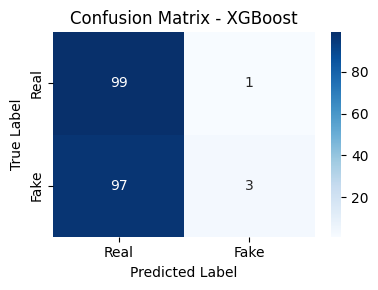

(0.51, 0.75, 0.03, 0.057692307692307696)

In [37]:
y_ext_encoded = y_ext_true.map({"real": 0, "fake": 1})

# Now run your evaluation
xgb_clf.evaluate(X_ext_combined_aligned, y_ext_encoded)

## Making the Previous Approach Modular for Adversarial Testing

In this notebook, we modularize our entire text processing and feature engineering workflow.  
By turning it into a reusable function, we make it easy to **edit text inputs in an adversarial way** (e.g., adding noise, removing words, inserting misleading phrases) and **immediately test the impact** on the model's prediction.  

This flexible setup lets us:
- Create perturbed or manipulated text examples on the fly.
- Quickly transform them into a model-ready feature row.
- Evaluate how robust the model is to these adversarial changes.

This is essential for testing real-world model robustness and understanding how small edits can affect misinformation detection.

In [ ]:
from misinformation_detection.data import prepare_text_structured_features_full
from pathlib import Path

X_train_combined, X_test_combined, X_structured_train_full, X_structured_test_full, y_train, y_test, vectorizer = prepare_text_structured_features_full(
    DATA_PATH / Path("processed/fnn_lemmatized.csv")
)

Model loaded from /content/drive/MyDrive/MASAID/AI_Project_Course/Misinformation/repo/data/saved_checkpoints/xgboost_model.joblib
Accuracy: 0.8233, Precision: 0.7641, Recall: 0.3385, F1-score: 0.4692


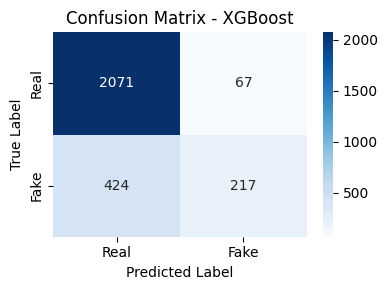

(0.8233177401943145,
 0.7640845070422535,
 0.33853354134165364,
 0.46918918918918917)

In [ ]:

from misinformation_detection.models import XGBoostModel

# Convert labels to numeric: real=0, fake=1
y_train_encoded = y_train.map({"real": 0, "fake": 1})
y_test_encoded = y_test.map({"real": 0, "fake": 1})

# 1. Initialize and train
xgb_clf = XGBoostModel(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    use_label_encoder=False,
    eval_metric="logloss",
    random_state=42
)

xgb_clf.load_model(SAVED_CHECKPOINTS_PATH / Path("xgboost_model.joblib"))

xgb_clf.evaluate(X_test_combined, y_test_encoded)

In [ ]:
import re
import nltk
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
from textstat import flesch_reading_ease
import numpy as np
import pandas as pd

# One-time NLTK downloads
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')
nltk.download('stopwords')
nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger_eng')


# Shared objects
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))
clickbait_phrases = [
    "you won’t believe", "what happened next", "shocking", "this is why",
    "top 10", "goes viral", "are freaking out", "epic fail", "can’t stop laughing"
]

# --- Helper functions ---
def clean_text(text):
    text = str(text).lower().strip()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"<[^>]+>", "", text)
    text = re.sub(r"[^\x20-\x7E]", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text

def lemmatize_text(text):
    tokens = word_tokenize(text)
    return " ".join(lemmatizer.lemmatize(token) for token in tokens)

def word_count(text):
    tokens = word_tokenize(text)
    return len(tokens)

def sentence_count(text):
    sentences = sent_tokenize(text)
    return len(sentences)

def avg_word_length(text):
    tokens = word_tokenize(text)
    return np.mean([len(w) for w in tokens]) if tokens else 0

def lexical_richness(text):
    tokens = word_tokenize(text)
    return len(set(tokens)) / len(tokens) if tokens else 0

def pos_ratios(text):
    tokens = word_tokenize(text)
    if not tokens:
        return 0, 0, 0
    tags = nltk.pos_tag(tokens)
    total = len(tags)
    noun_ratio = sum(1 for _, tag in tags if tag.startswith('NN')) / total
    verb_ratio = sum(1 for _, tag in tags if tag.startswith('VB')) / total
    adj_ratio  = sum(1 for _, tag in tags if tag.startswith('JJ')) / total
    return noun_ratio, verb_ratio, adj_ratio

def punctuation_count(text):
    return sum(1 for c in str(text) if c in "!\"#$%&'()*+,-./:;<=>?@[\\]^_`{|}~")

def exclamation_count(text):
    return str(text).count("!")

def exclamation_ratio(text):
    tokens = word_tokenize(text)
    return str(text).count("!") / len(tokens) if tokens else 0

def stopword_ratio(text):
    tokens = word_tokenize(text)
    return sum(1 for w in tokens if w in stop_words) / len(tokens) if tokens else 0

def flesch_score(text):
    return flesch_reading_ease(text)

def has_clickbait(text):
    text = str(text).lower()
    return int(any(phrase in text for phrase in clickbait_phrases))

# --- Main transform function ---
def transform_text_to_row(input_text, vectorizer, train_feature_names):
    # 1) Clean and lemmatize
    cleaned = clean_text(input_text)
    lemmatized = lemmatize_text(cleaned)

    # 2) Create structured features
    word_cnt = word_count(cleaned)
    sent_cnt = sentence_count(cleaned)
    avg_wlen = avg_word_length(cleaned)
    lex_rich = lexical_richness(cleaned)
    noun_ratio, verb_ratio, adj_ratio = pos_ratios(cleaned)
    punct_cnt = punctuation_count(cleaned)
    excl_cnt = exclamation_count(cleaned)
    excl_ratio = exclamation_ratio(cleaned)
    stopw_ratio = stopword_ratio(cleaned)
    flesch = flesch_score(cleaned)
    clickbait = has_clickbait(cleaned)

    # 3) Dummy source features — set Other=True, all else False
    source_cols = ['source_billboard.com', 'source_dailymail.co.uk', 'source_elle.com',
                   'source_en.wikipedia.org', 'source_etonline.com', 'source_ew.com',
                   'source_harpersbazaar.com', 'source_hollywoodreporter.com',
                   'source_inquisitr.com', 'source_people.com', 'source_radaronline.com',
                   'source_thewrap.com', 'source_today.com', 'source_usmagazine.com',
                   'source_variety.com']
    source_features = {col: False for col in source_cols}
    source_features["source_Other"] = True  # all go to Other

    # 4) TF-IDF
    tfidf_vec = vectorizer.transform([lemmatized])
    tfidf_df = pd.DataFrame(
        tfidf_vec.toarray(),
        columns=vectorizer.get_feature_names_out()
    )

    # 5) Combine
    structured_data = pd.DataFrame([{
        "word_count": word_cnt,
        "sentence_count": sent_cnt,
        "avg_word_length": avg_wlen,
        "lexical_richness": lex_rich,
        "noun_ratio": noun_ratio,
        "verb_ratio": verb_ratio,
        "adj_ratio": adj_ratio,
        "punctuation_count": punct_cnt,
        "exclamation_count": excl_cnt,
        "exclamation_ratio": excl_ratio,
        "stopword_ratio": stopw_ratio,
        "flesch_reading_ease": flesch,
        "has_clickbait": clickbait,
        **source_features
    }])

    combined = pd.concat([tfidf_df, structured_data], axis=1)

    # 6) Align to training feature names
    final_row = combined.reindex(columns=train_feature_names, fill_value=0)

    return final_row

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


In [ ]:
test = transform_text_to_row("test sentence for feature extraction", vectorizer, X_train_combined.columns.tolist())
print(test)

    10  2017  2018  according  actor  actress  award  baby  best  big  ...  \
0  0.0   0.0   0.0        0.0    0.0      0.0    0.0   0.0   0.0  0.0  ...   

   exclamation_count  stopword_count  has_clickbait  exclamation_ratio  \
0                  0               0              0                0.0   

   stopword_ratio  flesch_reading_ease  noun_ratio  verb_ratio  adj_ratio  \
0             0.2                49.48         0.8         0.0        0.0   

   missing_valid_url  
0                  0  

[1 rows x 131 columns]


## Examining XGBoost Feature Importances for Adversarial Example Design

Before we create adversarial misinformation examples,  
we first analyze our trained **XGBoost model’s feature importances**, using both the built-in importance scores and **SHAP** values.

By understanding which words, TF-IDF tokens, or structural features (like word count, clickbait flags, or specific source flags) the model relies on most,  
we can design more targeted perturbations. For example:
- Remove or replace highly influential words.
- Add or amplify misleading phrases.
- Adjust structural signals like punctuation, exclamation points, or stopword ratios.

Using **SHAP** also helps us see whether a feature pushes predictions towards **real (0)** or **fake (1)** — so we can craft edits that test the model’s sensitivity.

This insight will help us craft **more effective adversarial tests** and explore how fragile or robust our classifier is to subtle text changes.

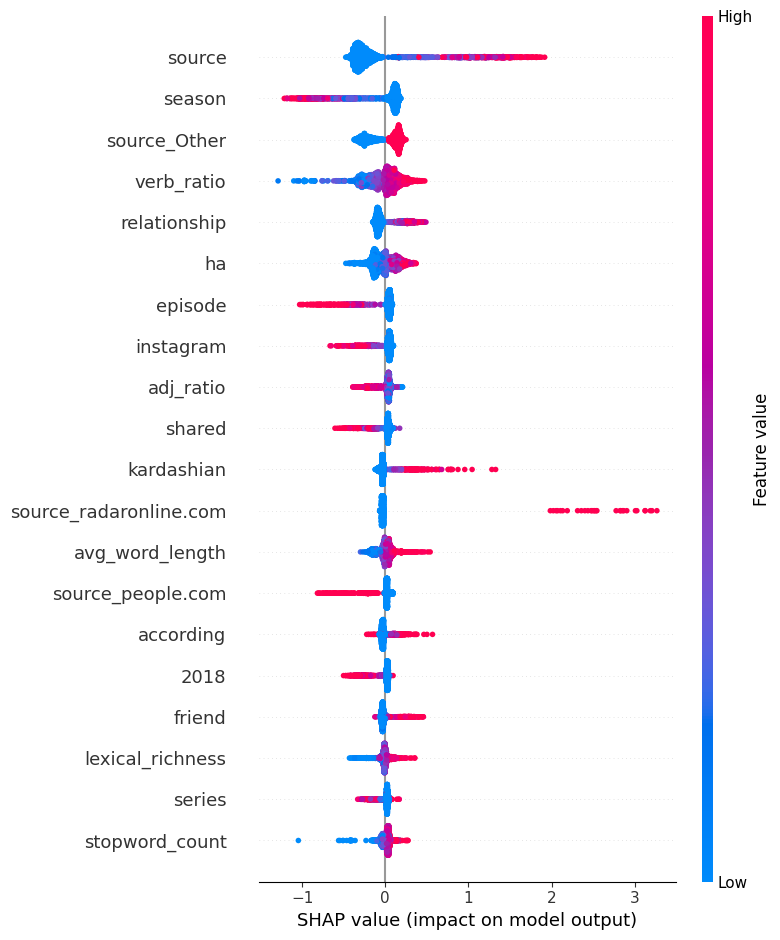

In [ ]:
import shap

# Create explainer
explainer = shap.TreeExplainer(xgb_clf.model)

# Calculate SHAP values for your test data
shap_values = explainer.shap_values(X_test_combined)

# Make summary plot
shap.summary_plot(shap_values, X_test_combined)

## Selecting Confident Examples for Adversarial Testing

Before designing adversarial edits,  
we first identify **examples from the test set that the model is very confident about**.

- **Confident REAL**: articles correctly predicted as real with very low probability of being fake.
- **Confident FAKE**: articles correctly predicted as fake with very high probability of being fake.

These samples are useful because they let us see  
**how much manipulation is needed to flip a prediction** for the most certain cases.

In [ ]:
import numpy as np

# Get predicted probabilities for class 1 (fake)
y_test_proba = xgb_clf.model.predict_proba(X_test_combined)[:, 1]

# Add to your test DataFrame
X_structured_test_full = X_structured_test_full.copy()
X_structured_test_full["true_label"] = y_test.map({"real": 0, "fake": 1}).values
X_structured_test_full["predicted_label"] = xgb_clf.predict(X_test_combined)
X_structured_test_full["predicted_proba_fake"] = y_test_proba

# Filter for correct predictions only
X_structured_test_full["is_correct"] = (
    X_structured_test_full["true_label"] == X_structured_test_full["predicted_label"]
)

# Confident REAL examples: predicted real with low probability for fake
confident_real = X_structured_test_full[
    (X_structured_test_full["is_correct"]) &
    (X_structured_test_full["true_label"] == 0) &
    (X_structured_test_full["predicted_proba_fake"] < 0.1)
]

# Confident FAKE examples: predicted fake with high probability for fake
confident_fake = X_structured_test_full[
    (X_structured_test_full["is_correct"]) &
    (X_structured_test_full["true_label"] == 1) &
    (X_structured_test_full["predicted_proba_fake"] > 0.9)
]

print(f"Confident REAL samples: {len(confident_real)}")
print(f"Confident FAKE samples: {len(confident_fake)}")

# Quick peek
confident_real.head(2)

Confident REAL samples: 790
Confident FAKE samples: 25


,id,title,label,dataset_source,source_domain,article_cleaned,date_cleaned,source_domain.1,source_domain_grouped,source_Other,...,flesch_reading_ease,noun_ratio,verb_ratio,adj_ratio,article_lemmatized,missing_valid_url,true_label,predicted_label,predicted_proba_fake,is_correct
7653,gossipcop-871753,Miley pens sweet message to Liam Hemsworth and...,real,gossipcop,dailytimes.com.pk,"talk about a cozy lazy sunday! earlier, miley ...",10/08/2017,dailytimes.com.pk,Other,True,...,68.707245,0.208075,0.164596,0.105590,"talk about a cozy lazy sunday ! earlier , mile...",False,0,0,0.082952,True
4121,gossipcop-849929,FX Pulls the Plug On Marvel’s Deadpool Animate...,real,gossipcop,deadline.com,fx is not going forward with its marvel s dead...,25/03/2018,deadline.com,Other,True,...,47.556724,0.315582,0.136095,0.110454,fx is not going forward with it marvel s deadp...,False,0,0,0.085864,True


In [ ]:
confident_fake.head(2)

,id,title,label,dataset_source,source_domain,article_cleaned,date_cleaned,source_domain.1,source_domain_grouped,source_Other,...,flesch_reading_ease,noun_ratio,verb_ratio,adj_ratio,article_lemmatized,missing_valid_url,true_label,predicted_label,predicted_proba_fake,is_correct
1981,gossipcop-2710743535,Steve Harvey & Wife Caught In $400 Million Div...,fake,gossipcop,radaronline.com,family feud funnyman steve harvey is facing a ...,05/07/2018,radaronline.com,radaronline.com,False,...,49.500714,0.322917,0.156250,0.093750,family feud funnyman steve harvey is facing a ...,False,1,1,0.916808,True
2056,gossipcop-10448753,Roseanne Barr ‘Miserable’ & Going ‘Off the Dee...,fake,gossipcop,radaronline.com,roseanne barr is still devastated two weeks af...,14/06/2018,radaronline.com,radaronline.com,False,...,56.642632,0.275229,0.183486,0.082569,roseanne barr is still devastated two week aft...,False,1,1,0.949147,True


## Examining How the Model Makes Its Prediction

Next, we select one confident example and inspect **why the model predicted it as real**.

- We transform the raw text into the same feature format the model expects.
- We force the source dummies for consistency.
- We run the example through the model to get its predicted label and probability.
- We then use **SHAP** to visualize how individual features contributed to the prediction.

This helps us see which words, sources, or structural signals pushed the model towards classifying the article as real or fake.

Original text:
 talk about a cozy lazy sunday! earlier, miley cyrus shared a sweet instagram message with her main man liam hemsworth from the comfort of her bed. the we can t stop singer posted the three images on social media, which featured the sleepy star cuddling with their labradoodle pup dora, who was named after the nickelodeon show. along with the too-cute images, the 24-year-old wrote, we miss you @liamhemsworth! an hour before miley cyrus penned her affectionate post, liam hemsworth hopped on instagram and shared an image of himself and the pup with the caption, #thuglife. cyrus commented, lucky to have you babies to cuddle and then posted her message back to her long-term love. back in 2015, cyrus helped the aussie actor adopt dora from wylder s holistic pet centre & rescue in la s studio city neighbourhood. the two took to social media during the outing and their posts ignited rumours that the two had rekindled their broken romance, which turned out to be true. since recon

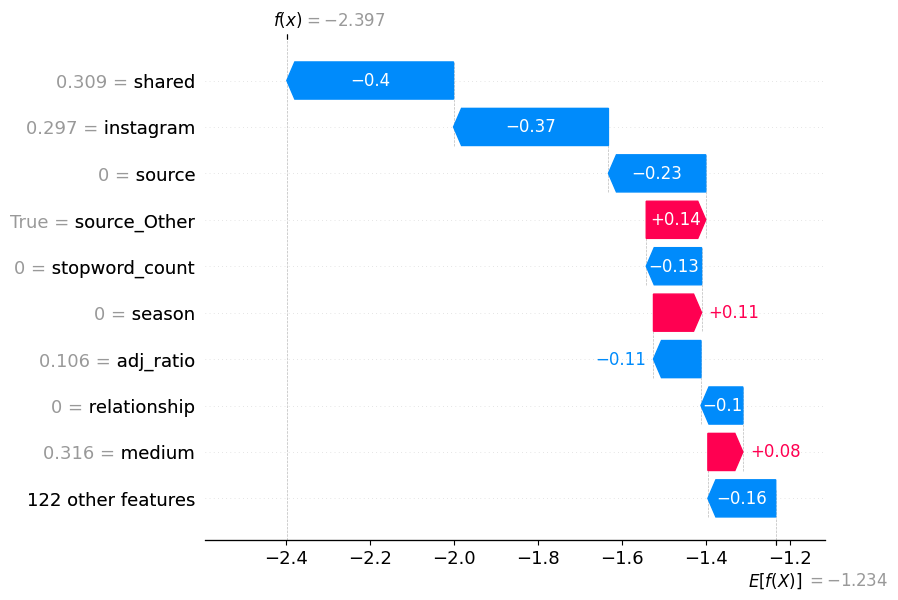

In [ ]:
import shap

# === Pick one confident real example ===
sample_real = confident_real.iloc[0]
original_text = sample_real["article_cleaned"]

print("Original text:\n", original_text)

# === Transform ===
X_original_row = transform_text_to_row(
    input_text=original_text,
    vectorizer=vectorizer,
    train_feature_names=X_train_combined.columns
)

# Force all source dummies to False, except Other
for col in X_original_row.columns:
    if col.startswith("source_"):
        X_original_row[col] = False
X_original_row["source_Other"] = True

# Align
X_original_row = X_original_row.reindex(columns=X_train_combined.columns)

# === Predict ===
original_pred_label = xgb_clf.predict(X_original_row)[0]
original_pred_prob = xgb_clf.model.predict_proba(X_original_row)[0][1]

print(f"\nPredicted Label: {original_pred_label} (0=real, 1=fake)")
print(f"Predicted Probability (fake): {original_pred_prob:.4f}")

# === Explain with SHAP ===
explainer = shap.TreeExplainer(xgb_clf.model)
shap_values_original = explainer(X_original_row)

# === Visualize ===
shap.plots.waterfall(shap_values_original[0])

## Adding Adversarial Perturbations

Now we modify the same confident example by adding words and source cues that the model strongly associates with fake news — for example:

- Adding keywords like *“kardashian”, “relationship”, “shocking episode”, “you won’t believe”*  
- Changing the source feature to a domain that often appears in fake examples.

We then:
- Transform the adversarial text into model-ready features.
- Predict the new label and probability.
- Visualize with SHAP how these added features push the model’s prediction closer to *fake*.

This demonstrates how easily subtle changes can shift model confidence.

 Adversarial text:
 talk about a cozy lazy sunday! earlier, miley cyrus shared a sweet instagram message with her main man liam hemsworth from the comfort of her bed. the we can t stop singer posted the three images on social media, which featured the sleepy star cuddling with their labradoodle pup dora, who was named after the nickelodeon show. along with the too-cute images, the 24-year-old wrote, we miss you @liamhemsworth! an hour before miley cyrus penned her affectionate post, liam hemsworth hopped on instagram and shared an image of himself and the pup with the caption, #thuglife. cyrus commented, lucky to have you babies to cuddle and then posted her message back to her long-term love. back in 2015, cyrus helped the aussie actor adopt dora from wylder s holistic pet centre & rescue in la s studio city neighbourhood. the two took to social media during the outing and their posts ignited rumours that the two had rekindled their broken romance, which turned out to be true. since r

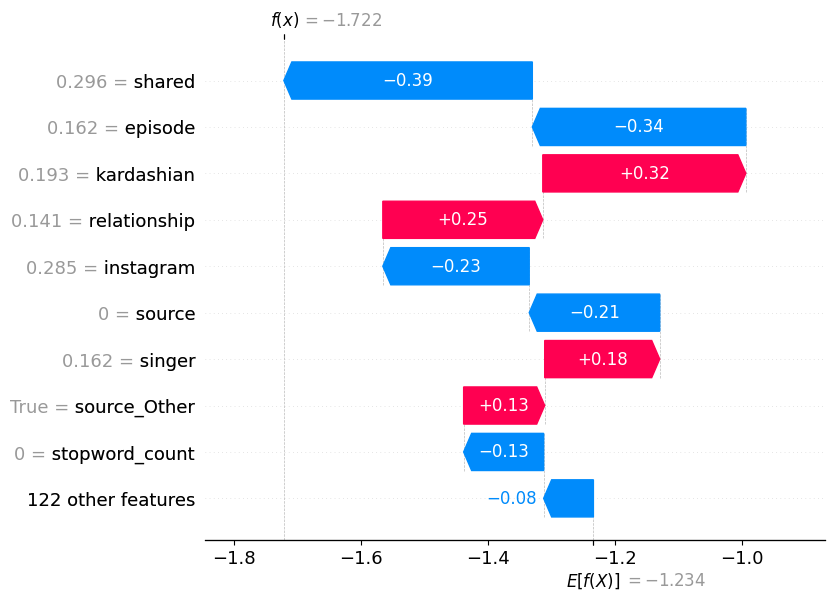

In [ ]:
import shap

# === Example: Add adversarial tokens ===
adversarial_text = original_text + "epic fail kardashian relationship shocking episode you won’t believe"

print(" Adversarial text:\n", adversarial_text)

# === Transform ===
X_adv_row = transform_text_to_row(
    input_text=adversarial_text,
    vectorizer=vectorizer,
    train_feature_names=X_train_combined.columns
)

# Force all source dummies to False except Other
for col in X_adv_row.columns:
    if col.startswith("source_"):
        X_adv_row[col] = False
X_adv_row["source_Other"] = True

# Align columns
X_adv_row = X_adv_row.reindex(columns=X_train_combined.columns)

# === Predict ===
adv_pred_label = xgb_clf.predict(X_adv_row)[0]
adv_pred_prob = xgb_clf.model.predict_proba(X_adv_row)[0][1]

print(f"\n Predicted Label: {adv_pred_label} (0=real, 1=fake)")
print(f" Predicted Probability (fake): {adv_pred_prob:.4f}")

# === Explain with SHAP ===
explainer = shap.TreeExplainer(xgb_clf.model)
shap_values_adv = explainer(X_adv_row)

# === Visualize ===
shap.plots.waterfall(shap_values_adv[0])

## Pushing the Adversarial Perturbation Further

The first adversarial edits were not enough to flip the model’s prediction confidently.  
So now, we amplify the perturbation by:

- Replacing neutral or negative-impact words (*“episode”, “source”*) with less negative alternatives.
- Injecting even more high-impact fake signals (*“kardashian”, “shocking”, “viral”* multiple times).
- Switching the source domain to a fake-heavy domain.

This helps us observe how much stronger perturbations can manipulate the model’s confidence and flip its decision.

talk about a cozy lazy sunday! earlier, miley cyrus shared a sweet instagram message with her main man liam hemsworth from the comfort of her bed. the we can t stop singer posted the three images on social media, which featured the sleepy star cuddling with their labradoodle pup dora, who was named after the nickelodeon show. along with the too-cute images, the 24-year-old wrote, we miss you @liamhemsworth! an hour before miley cyrus penned her affectionate post, liam hemsworth hopped on instagram and shared an image of himself and the pup with the caption, #thuglife. cyrus commented, lucky to have you babies to cuddle and then posted her message back to her long-term love. back in 2015, cyrus helped the aussie actor adopt dora from wylder s holistic pet centre & rescue in la s studio city neighbourhood. the two took to social media during the outing and their posts ignited rumours that the two had rekindled their broken romance, which turned out to be true. since reconciling after the

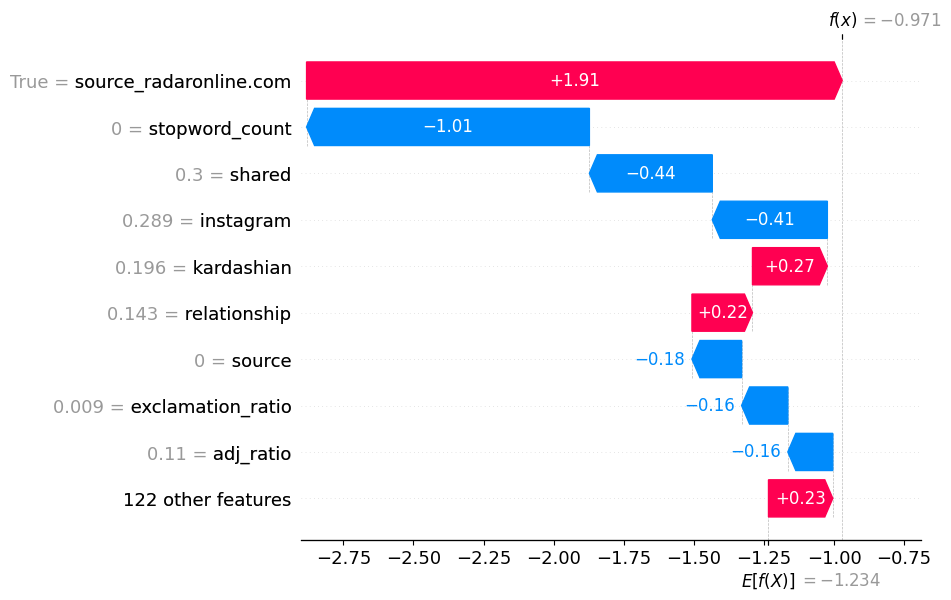

In [ ]:
# Try to neutralize negative words and add more fake signals
better_adv_text = original_text.replace("episode", "story").replace("source", "news")
better_adv_text += " kardashian shocking relationship viral shocking shocking shocking"

print(better_adv_text)

X_adv_row = transform_text_to_row(
    input_text=better_adv_text,
    vectorizer=vectorizer,
    train_feature_names=X_train_combined.columns
)
X_adv_row["source_radaronline.com"] = True
X_adv_row["source_Other"] = False

# Predict & plot
adv_pred_label = xgb_clf.predict(X_adv_row)[0]
adv_pred_prob = xgb_clf.model.predict_proba(X_adv_row)[0][1]

print(f"Label: {adv_pred_label}, Prob(fake): {adv_pred_prob:.4f}")

explainer = shap.TreeExplainer(xgb_clf.model)
shap_values_adv = explainer(X_adv_row)
shap.plots.waterfall(shap_values_adv[0])

## Systematic Adversarial Tests with `nlpaug`

To go beyond manual edits,  
we will use the **`nlpaug`** library to systematically perturb our test examples:  
- Randomly **remove** or **swap** words in the text.
- **Substitute** words with synonyms or similar words.
- Insert distracting phrases that might confuse the classifier.

After these controlled perturbations,  
we’ll **re-calculate the predictions** and measure how much the overall **accuracy** and other metrics drop.

This allows us to test how robust (or fragile) the model is  
under realistic noise and adversarial attacks in real-world settings.

In [ ]:
import nlpaug.augmenter.word as naw

# === Create augmenters ===

# Synonym replacement using WordNet
synonym_aug = naw.SynonymAug(aug_src='wordnet')

# Random word deletion
delete_aug = naw.RandomWordAug(action="delete")

# Random word swapping
swap_aug = naw.RandomWordAug(action="swap")

# === Example usage ===

example_text = "This is a simple example sentence to demonstrate how we can augment text."

print("Original:", example_text)
print("Synonym:", synonym_aug.augment(example_text))
print("Deleted:", delete_aug.augment(example_text))
print("Swapped:", swap_aug.augment(example_text))

Original: This is a simple example sentence to demonstrate how we can augment text.
Synonym: ['This is a simple case sentence to demonstrate how we can augment textual matter.']
Deleted: ['Is simple example sentence to demonstrate how we text.']
Swapped: ['This simple is a sentence example to demonstrate how can we text augment.']


## Systematic Text Perturbations with NLP Augmentations

In this step, we systematically generate **adversarial perturbations** on the test set  
using the **`nlpaug`** library.  
We apply three augmentation strategies in parallel:
- **Synonym Replacement:** Replace words with synonyms.
- **Random Word Deletion:** Remove random words.
- **Random Word Swap:** Swap positions of random words.

This allows us to test how sensitive our model is to small changes in wording and structure.  
Below you can see an example comparison between the original and augmented versions.

In [ ]:
import nlpaug.augmenter.word as naw
from tqdm import tqdm

# === Create augmenters ===
synonym_aug = naw.SynonymAug(aug_src='wordnet')
delete_aug = naw.RandomWordAug(action="delete")
swap_aug   = naw.RandomWordAug(action="swap")
rand_ind = ((np.random.random(150)*len(X_structured_test_full)).astype(int))
X_text_fraction = X_structured_test_full["article_cleaned"].iloc[rand_ind]
X_text_test_syn = []
X_text_test_del = []
X_text_test_swap = []

for text in tqdm(X_text_fraction):
    X_text_test_syn.append(synonym_aug.augment(text))
    X_text_test_del.append(delete_aug.augment(text))
    X_text_test_swap.append(swap_aug.augment(text))

# print("\n Example original vs augmented:")
print("Original:", X_text_fraction.iloc[0])
print("Synonym:", X_text_test_syn[0])
print("Delete:", X_text_test_del[0])
print("Swap:", X_text_test_swap[0])

100%|██████████| 150/150 [00:04<00:00, 30.99it/s]

Original: in the almost-seven minute clip, eminem and an unseen director talk about his fictional relationship with a married woman. it's a visual that begins with all the jazz surrounding romantic connection and ends with an unexpected pregnancy, which mirrors the bars to the collab. "my personal life is not exactly a highlight reel," eminem says at the start of the clip when he's asked what love means to him. sheeran appears sporadically throughout the clip, but the main character of this video is the crumbling connection between em and his fictional lover. it's clear that slim shady's unfortunate tale of romance in "river" goes along with his brand. "unhappy valentine's day! #river music video ft. @edsheeran wednesday," he tweeted earlier this week ahead of the video release. "river" is the second single from his recently-released lp, revival. scroll on below to see just how poorly things pan out for eminem's on-screen romance.
Synonym: ['in the near - seven minute clip, eminem and 

## Rebuild Feature Matrices for Each Perturbed Test Set

After generating the augmented versions of the test articles,  
we **recreate all features** for each version using our `transform_text_to_row` pipeline:  
- TF-IDF vectors  
- Structural features (word counts, ratios, clickbait flags, etc.)  
- Dummy source columns

This ensures that each perturbation can be tested on the same trained model,  
and we can measure how accuracy changes across **synonym replacement**, **word deletion**, and **word swapping**.

Below we check the final shapes to confirm the new test feature matrices are ready.

In [ ]:
# Container for each version
rows_syn, rows_del, rows_swap = [], [], []

for text in tqdm(X_text_test_syn):
    row = transform_text_to_row(text, vectorizer, X_train_combined.columns)
    rows_syn.append(row)

for text in tqdm(X_text_test_del):
    row = transform_text_to_row(text, vectorizer, X_train_combined.columns)
    rows_del.append(row)

for text in tqdm(X_text_test_swap):
    row = transform_text_to_row(text, vectorizer, X_train_combined.columns)
    rows_swap.append(row)

# Combine to DataFrames
X_test_syn_combined = pd.concat(rows_syn, ignore_index=True)
X_test_del_combined = pd.concat(rows_del, ignore_index=True)
X_test_swap_combined = pd.concat(rows_swap, ignore_index=True)

print(f" Synonym shape: {X_test_syn_combined.shape}")
print(f" Delete shape:  {X_test_del_combined.shape}")
print(f" Swap shape:    {X_test_swap_combined.shape}")

100%|██████████| 150/150 [00:08<00:00, 17.88it/s]

 Synonym shape: (150, 131)
 Delete shape:  (150, 131)
 Swap shape:    (150, 131)


## Evaluate Accuracy Drop After Systematic Perturbations

Finally, we test how the model’s accuracy changes under each type of **systematic text augmentation**:

- **Synonym Replacement**: Replaces words with their synonyms.
- **Random Word Deletion**: Randomly removes words from the text.
- **Random Word Swapping**: Swaps positions of random word pairs.

By comparing these accuracies to the original test set,  
we can measure how robust our classifier is to small edits and noise in the input data.

In [ ]:
from sklearn.metrics import accuracy_score

# True labels
y_test_encoded = y_test.map({"real": 0, "fake": 1}).values

# Synonym
pred_syn = xgb_clf.predict(X_test_syn_combined)
acc_syn = accuracy_score(y_test_encoded[rand_ind], pred_syn)

# Delete
pred_del = xgb_clf.predict(X_test_del_combined)
acc_del = accuracy_score(y_test_encoded[rand_ind], pred_del)

# Swap
pred_swap = xgb_clf.predict(X_test_swap_combined)
acc_swap = accuracy_score(y_test_encoded[rand_ind], pred_swap)

print(f" Original Accuracy: {accuracy_score(y_test_encoded[rand_ind], xgb_clf.predict(X_test_combined.iloc[rand_ind])):.4f}")
print(f" Synonym Accuracy:  {acc_syn:.4f}")
print(f" Delete Accuracy:   {acc_del:.4f}")
print(f" Swap Accuracy:     {acc_swap:.4f}")

 Original Accuracy: 0.8933
 Synonym Accuracy:  0.8600
 Delete Accuracy:   0.8600
 Swap Accuracy:     0.8667


## Testing Transformer Model Robustness with Augmentations

In this step, we will test our **RoBERTa transformer model** and evaluate its **robustness** against text augmentations.  
We’ll apply perturbations like **synonym replacement**, **word deletion**, and **word swapping** to the test set  
and compare how the transformer’s performance changes under these adversarial scenarios.

In [ ]:
from transformers import RobertaTokenizer
import pandas as pd
from sklearn.model_selection import train_test_split
import torch

# === 1) Read cleaned dataset ===
fnn_df = pd.read_csv(DATA_PATH / Path("processed/fnn_cleaned.csv"))
print(f" Loaded dataset shape: {fnn_df.shape}")
print(fnn_df.columns.tolist())
print(fnn_df['label'].value_counts())

# === 2) Create splits ===

# Encode labels: fake=0, real=1
fnn_df["label_enc"] = fnn_df["label"].map({"fake": 0, "real": 1})

# 80% train, 10% val, 10% test
train_texts, temp_texts, train_labels, temp_labels = train_test_split(
    fnn_df["article_cleaned"].tolist(),
    fnn_df["label_enc"].tolist(),
    test_size=0.2,
    stratify=fnn_df["label_enc"],
    random_state=42
)
val_texts, test_texts, val_labels, test_labels = train_test_split(
    temp_texts, temp_labels, test_size=0.5, stratify=temp_labels, random_state=42
)

print(f" Train: {len(train_texts)} | Val: {len(val_texts)} | Test: {len(test_texts)}")

# === 3) Tokenize ===

tokenizer = RobertaTokenizer.from_pretrained("roberta-base")

train_encodings = tokenizer(train_texts, truncation=True, padding=True, max_length=512)
val_encodings   = tokenizer(val_texts, truncation=True, padding=True, max_length=512)
test_encodings  = tokenizer(test_texts, truncation=True, padding=True, max_length=512)

print(" Tokenization complete.")

# === 4) Dataset class ===

class FNNDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item

train_dataset = FNNDataset(train_encodings, train_labels)
val_dataset   = FNNDataset(val_encodings, val_labels)
test_dataset  = FNNDataset(test_encodings, test_labels)

print(f" Dataset examples: {len(train_dataset)} train, {len(val_dataset)} val, {len(test_dataset)} test")

# === 5) DataLoaders ===
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=16)
test_loader  = DataLoader(test_dataset, batch_size=16)

print(" DataLoaders ready: Train, Validation, Test")

 Loaded dataset shape: (13892, 25)
['id', 'title', 'label', 'dataset_source', 'source_domain', 'article_cleaned', 'date_cleaned', 'source_domain.1', 'source_domain_grouped', 'source_Other', 'source_billboard.com', 'source_dailymail.co.uk', 'source_elle.com', 'source_en.wikipedia.org', 'source_etonline.com', 'source_ew.com', 'source_harpersbazaar.com', 'source_hollywoodreporter.com', 'source_inquisitr.com', 'source_people.com', 'source_radaronline.com', 'source_thewrap.com', 'source_today.com', 'source_usmagazine.com', 'source_variety.com']
label
real    10686
fake     3206
Name: count, dtype: int64
 Train: 11113 | Val: 1389 | Test: 1390


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

 Tokenization complete.
 Dataset examples: 11113 train, 1389 val, 1390 test
 DataLoaders ready: Train, Validation, Test


In [ ]:
# === 6) Load model ===
from transformers import RobertaForSequenceClassification
import torch

model = RobertaForSequenceClassification.from_pretrained("roberta-base", num_labels=2)

# === 7) Load your trained weights ===
state_dict = torch.load(
    SAVED_CHECKPOINTS_PATH / Path("roberta_fnn_model_2.pt"),
    map_location=torch.device("cpu")
)

with torch.no_grad():
    model.load_state_dict(state_dict)

# Select device
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

model.to(device)
print(f" Model loaded and moved to device: {device}")

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


 Model loaded and moved to device: cuda


## Sanity Check: Evaluate on Un-Augmented Test Set

- Use your `evaluate` function to run the final trained model on the **original** `test_loader`.
- Calculate and print:
  - Accuracy
  - Precision
  - Recall
  - F1-Score
- Confirms baseline performance **without** any augmentations.

In [ ]:
# === 8) Evaluate on UN-AUGMENTED test set ===
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import torch

def evaluate(model, loader):
    model.eval()
    preds, targets = [], []

    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits = outputs.logits
            predictions = torch.argmax(logits, dim=1)

            preds.extend(predictions.cpu().numpy())
            targets.extend(labels.cpu().numpy())

    acc = accuracy_score(targets, preds)
    precision, recall, f1, _ = precision_recall_fscore_support(targets, preds, average="binary")
    print(f" Test Accuracy:  {acc:.4f}")
    print(f"Precision:         {precision:.4f}")
    print(f"Recall:            {recall:.4f}")
    print(f"F1-Score:          {f1:.4f}")

# Evaluate
evaluate(model, test_loader)

 Test Accuracy:  0.8353
Precision:         0.8659
Recall:            0.9298
F1-Score:          0.8967


## Apply NLP Augmentations to Test Set

- Use `nlpaug` to create three augmenters: synonym replacement, random word deletion, and word swap.
- Loop over `test_texts` and generate augmented versions.
- Store them in `test_texts_syn`, `test_texts_del`, and `test_texts_swap`.
- Quick sanity check: print the original and augmented examples.

In [ ]:
import nlpaug.augmenter.word as naw
from tqdm import tqdm

# === Define augmenters ===
synonym_aug = naw.SynonymAug(aug_src='wordnet')
delete_aug  = naw.RandomWordAug(action="delete")
swap_aug    = naw.RandomWordAug(action="swap")

# === Apply augmentations ===
test_texts_syn  = []
test_texts_del  = []
test_texts_swap = []

for text in tqdm(test_texts, desc="Augmenting test set"):
    # Make sure each augment returns a plain string
    syn_aug = synonym_aug.augment(text, n=1)
    del_aug = delete_aug.augment(text)
    swap_aug_out = swap_aug.augment(text)

    # If augment returns list, get first element
    if isinstance(syn_aug, list):
        syn_aug = syn_aug[0]
    if isinstance(del_aug, list):
        del_aug = del_aug[0]
    if isinstance(swap_aug_out, list):
        swap_aug_out = swap_aug_out[0]

    test_texts_syn.append(syn_aug)
    test_texts_del.append(del_aug)
    test_texts_swap.append(swap_aug_out)

print("\n Example check:")
print("Original:", test_texts[0])
print("Synonym:", test_texts_syn[0])
print("Delete:", test_texts_del[0])
print("Swap:", test_texts_swap[0])

Augmenting test set: 100%|██████████| 1390/1390 [00:54<00:00, 25.55it/s]


 Example check:
Original: story highlights the couple got engaged in 2008 she said she was in no rush to marry cnn jennifer hudson and david otunga have split after 10 years. a representative for hudson provided cnn with a statement friday, saying the pair have been in the process of ending their relationship for a number of months. yesterday, jennifer requested and received a protective order against her ex-fianc , the statement read. jennifer s actions are solely taken in the best interest of their son. please respect her privacy at this time. an attorney for otunga told cnn his client has never abused or harassed ms. hudson or their son. he wants to make it very clear that he denies each and every allegation contained in that petition. mr. otunga is now and has always been the primary caregiver of the parties son, the statement read. the couple had been dating less than a year when otunga proposed to hudson in 2008. in 2012, he told wendy williams that hudson first noticed him when

In [ ]:
# Use your same tokenizer
test_encodings_syn  = tokenizer(test_texts_syn, truncation=True, padding=True, max_length=512)
test_encodings_del  = tokenizer(test_texts_del, truncation=True, padding=True, max_length=512)
test_encodings_swap = tokenizer(test_texts_swap, truncation=True, padding=True, max_length=512)

# Wrap as datasets using same class
test_dataset_syn  = FNNDataset(test_encodings_syn, test_labels)
test_dataset_del  = FNNDataset(test_encodings_del, test_labels)
test_dataset_swap = FNNDataset(test_encodings_swap, test_labels)

# Make loaders
test_loader_syn  = DataLoader(test_dataset_syn, batch_size=16)
test_loader_del  = DataLoader(test_dataset_del, batch_size=16)
test_loader_swap = DataLoader(test_dataset_swap, batch_size=16)

print(" Augmented test DataLoaders ready.")

 Augmented test DataLoaders ready.


Now we test.

In [ ]:
# Reuse your same evaluate() function:
evaluate(model, test_loader_syn)
evaluate(model, test_loader_del)
evaluate(model, test_loader_swap)

 Test Accuracy:  0.8345
Precision:         0.8670
Recall:            0.9270
F1-Score:          0.8960
 Test Accuracy:  0.8360
Precision:         0.8666
Recall:            0.9298
F1-Score:          0.8971
 Test Accuracy:  0.8388
Precision:         0.8677
Recall:            0.9326
F1-Score:          0.8990
